In [1]:
import time

import numpy as np

from physics_sim import Ball, DragForce, LinearGravityForce, NumpyPhysicsEngine


def build_engine(bounds=(20.0, 15.0)):
    """Create and configure engine."""
    engine = NumpyPhysicsEngine(bounds=bounds)
    engine.add_force(LinearGravityForce(np.array([0.0, -9.81])))
    engine.add_force(DragForce(linear=True))
    return engine


def run_benchmark(n_balls: int, n_steps: int = 600) -> dict:
    """Run benchmark and return timing data."""
    engine = build_engine()

    # Add balls
    start_add = time.perf_counter()
    for i in range(n_balls):
        x = (i % 20) + 1.0
        y = ((i // 20) % 10) + 1.0
        ball = Ball(
            position=np.array([x, y]),
            velocity=np.array([np.random.uniform(-5, 5), np.random.uniform(-5, 5)]),
            radius=0.15,
            mass=1.0,
            color=(255, 0, 0),
            restitution=0.9,
        )
        engine.add_entity(ball)
    add_time = time.perf_counter() - start_add

    # Run simulation
    dt = 1.0 / 60.0
    start_sim = time.perf_counter()
    steps_time = []
    for _ in range(n_steps):
        start_step = time.perf_counter()
        engine.step(dt)
        end_step = time.perf_counter()
        step_time = end_step - start_step
        steps_time.append(step_time)

    sim_time = time.perf_counter() - start_sim

    fps = n_steps / sim_time

    return {
        "n_balls": n_balls,
        "n_steps": n_steps,
        "add_time_s": add_time,
        "sim_time_s": sim_time,
        "steps_time": steps_time,
        "fps": fps,
        "ms_per_step": (sim_time / n_steps) * 1000.0,
    }


print("Physics Engine Performance Measurements")
print("=" * 60)


Physics Engine Performance Measurements


/Users/tomaszkoczar/Desktop/MLinPhysics/.venv/lib/python3.13/site-packages/pyglet/media/codecs/__init__.py:113: UserWarning: FFmpeg release version not found. This may be a new or untested release. Unknown behavior may occur. Versions Loaded: {'avcodec': 62, 'avformat': 62, 'avutil': 60, 'swresample': 6, 'swscale': 9}
  warnings.warn(f'FFmpeg release version not found. This may be a new or untested release. Unknown behavior may occur. Versions Loaded: {ffmpeg_lib.compat.versions}')


In [4]:
CASES = [10, 20, 50, 100, 1000, 2000]
NUM_STEPS = 100
res = {}
for case in CASES:
    res[case] = run_benchmark(case, n_steps=NUM_STEPS)

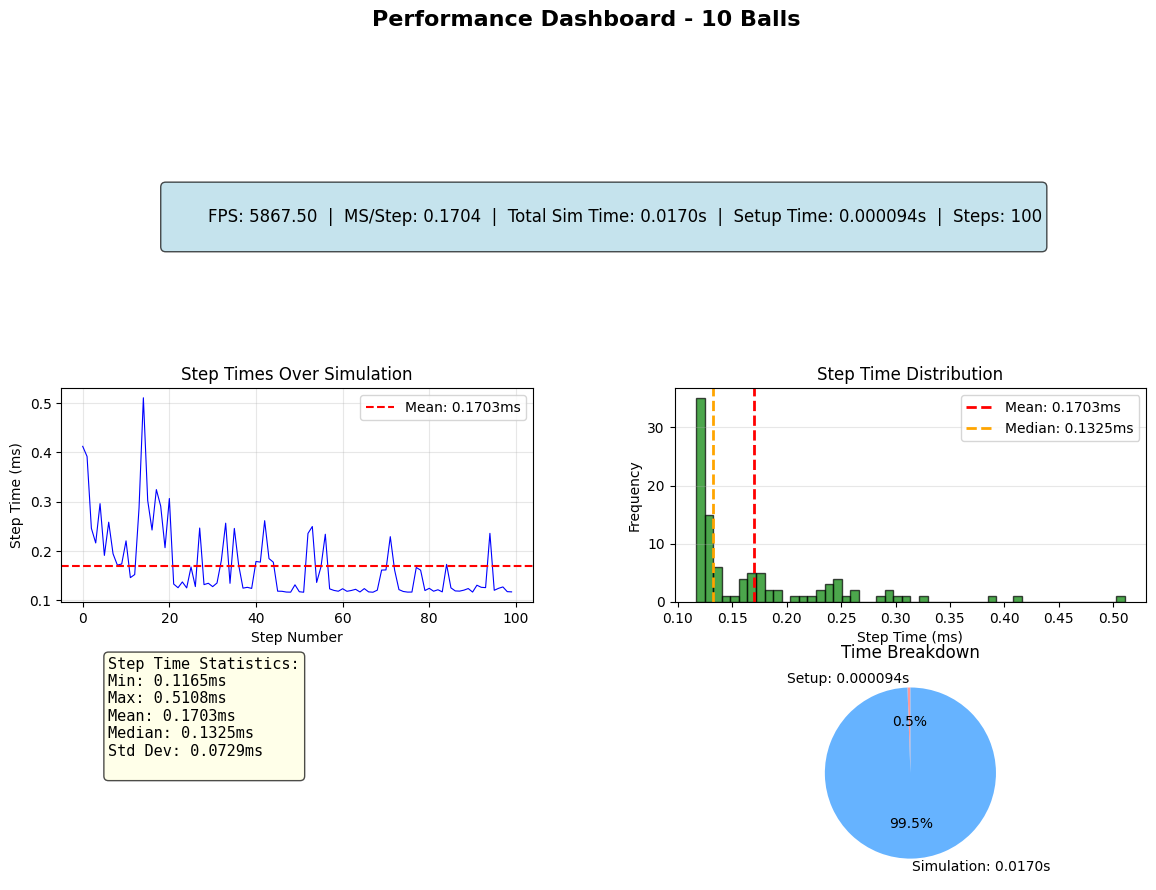

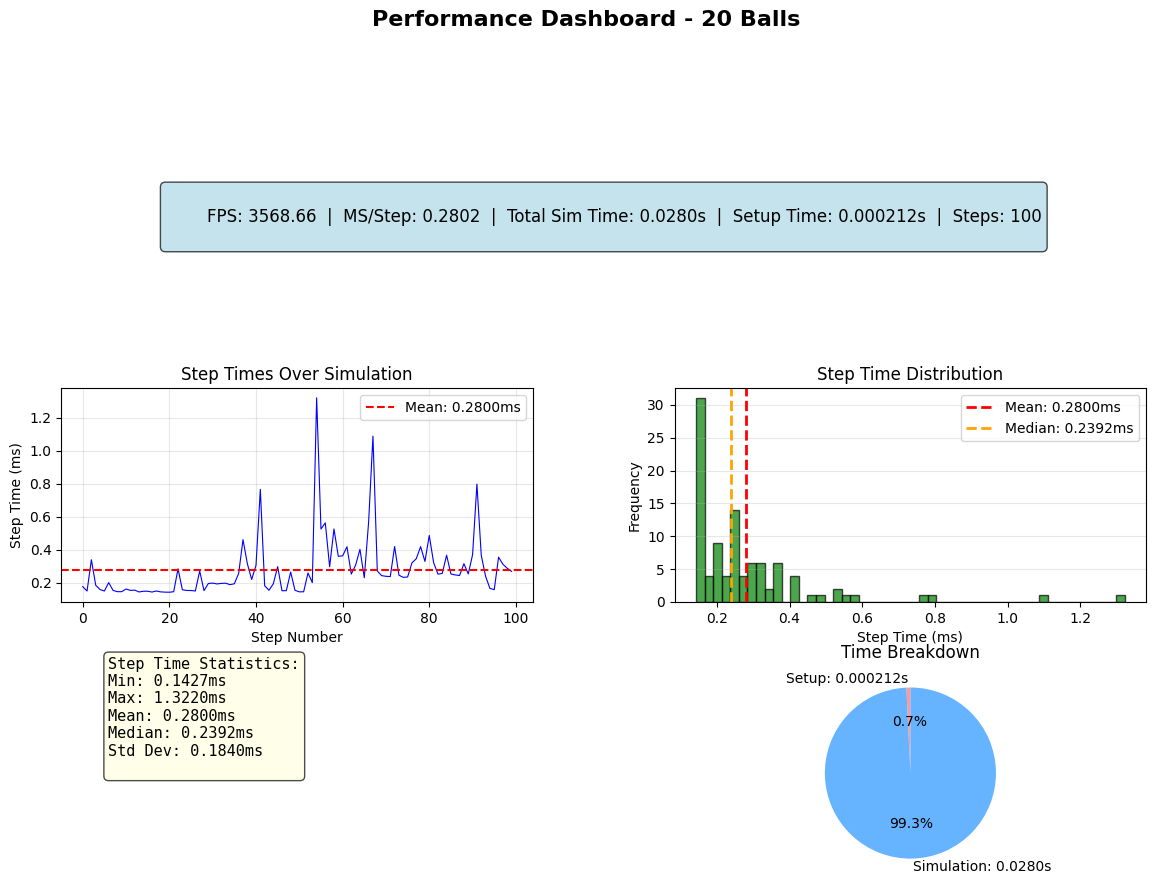

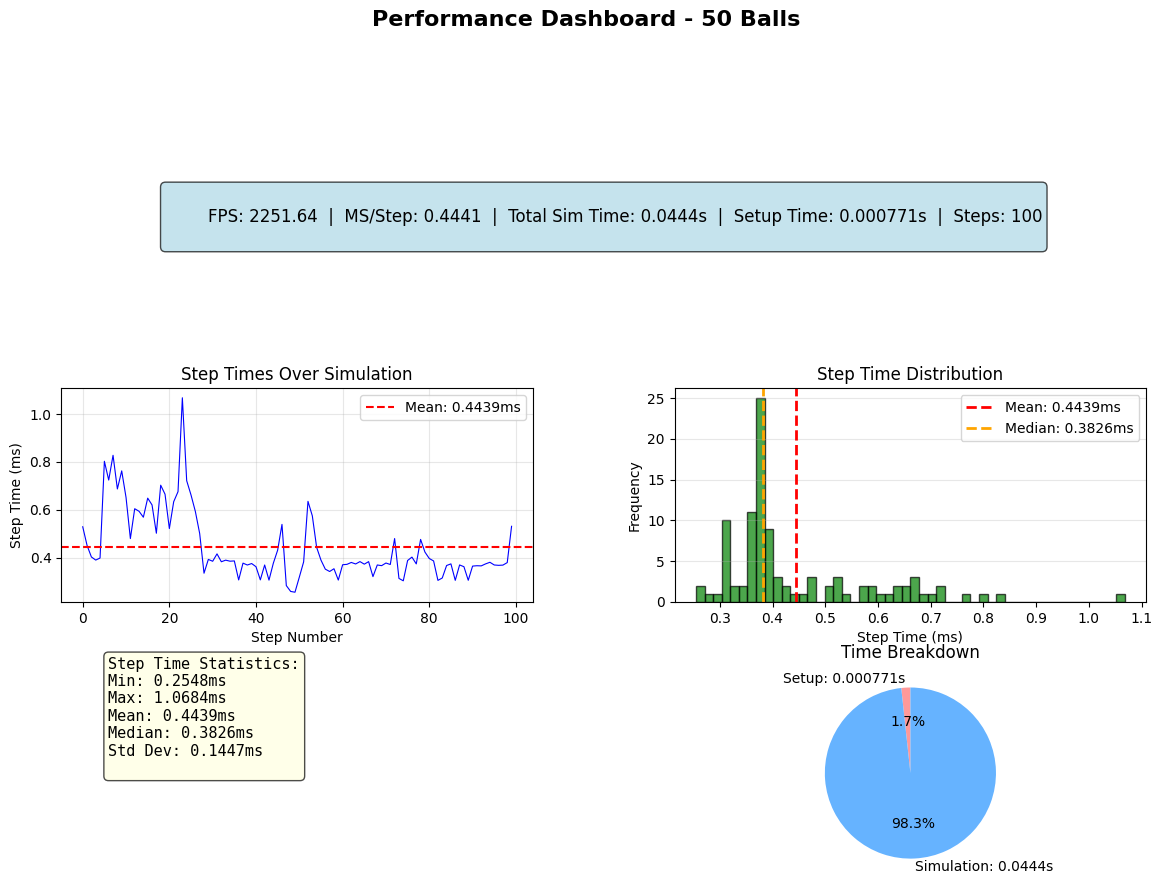

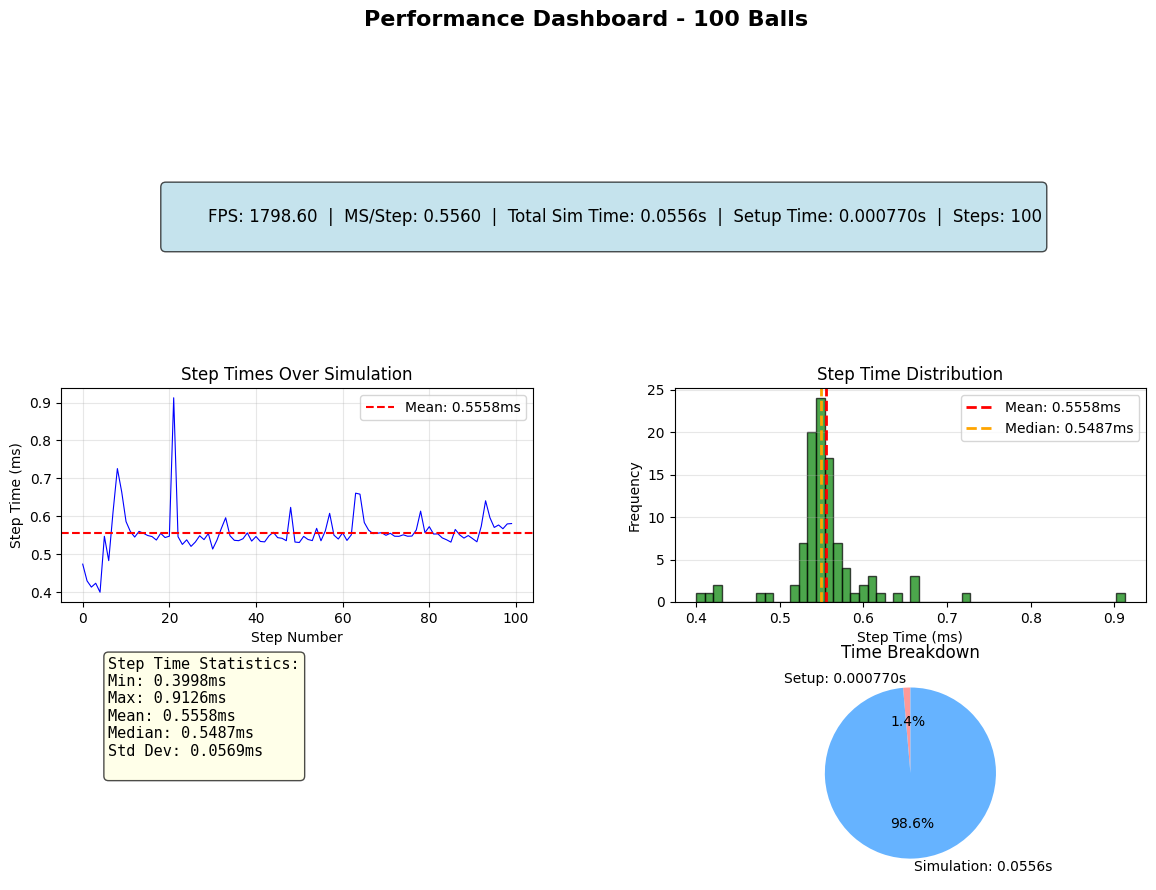

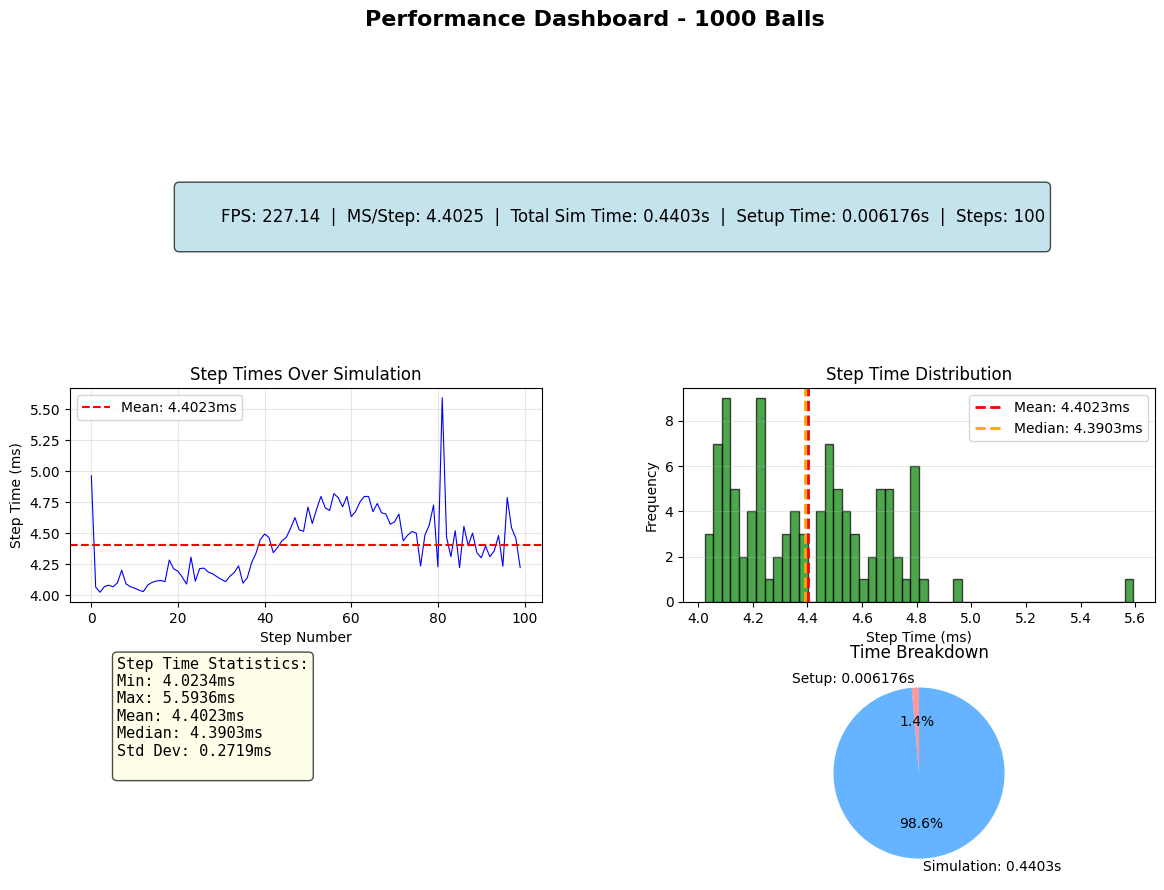

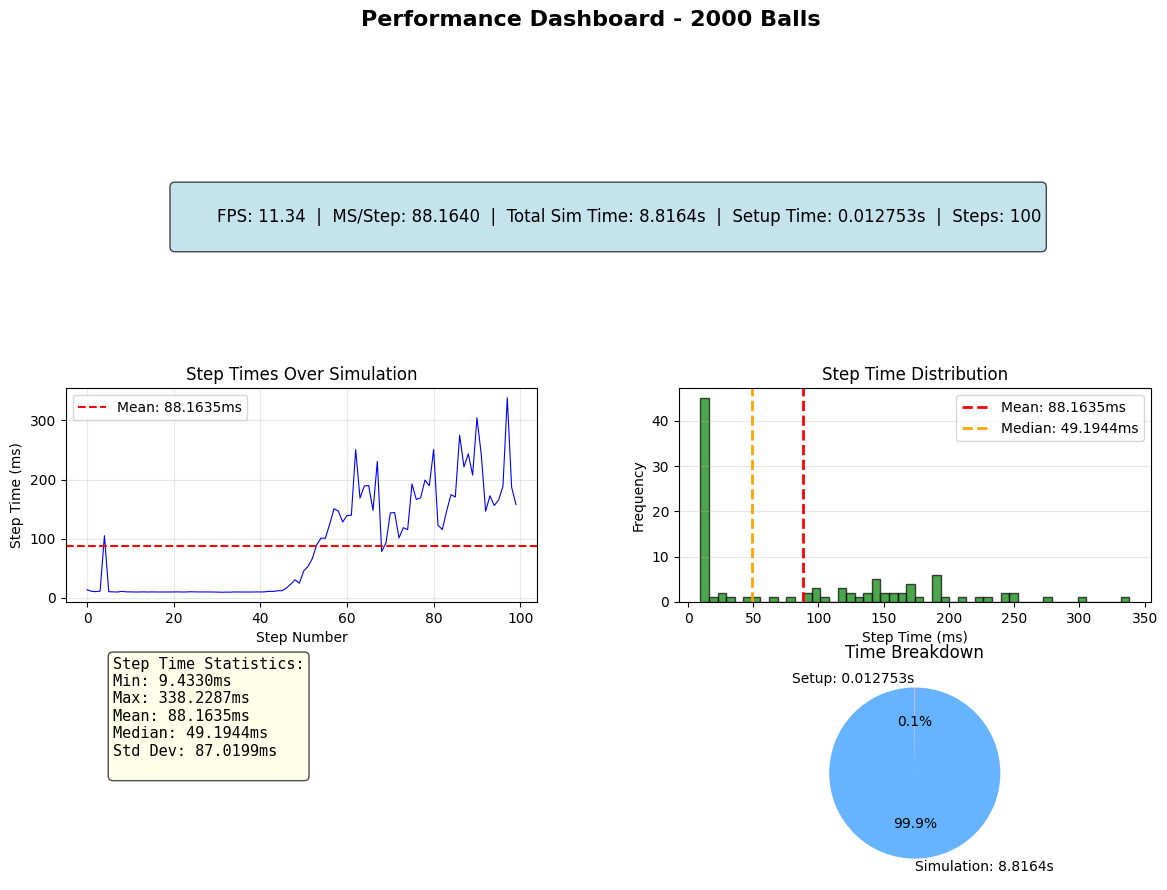

/var/folders/bb/573j0mcn4ds4f9crvgk_hmf00000gn/T/ipykernel_33491/4014611924.py:137: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax5.boxplot(step_times_all, labels=[str(c) for c in cases], patch_artist=True)


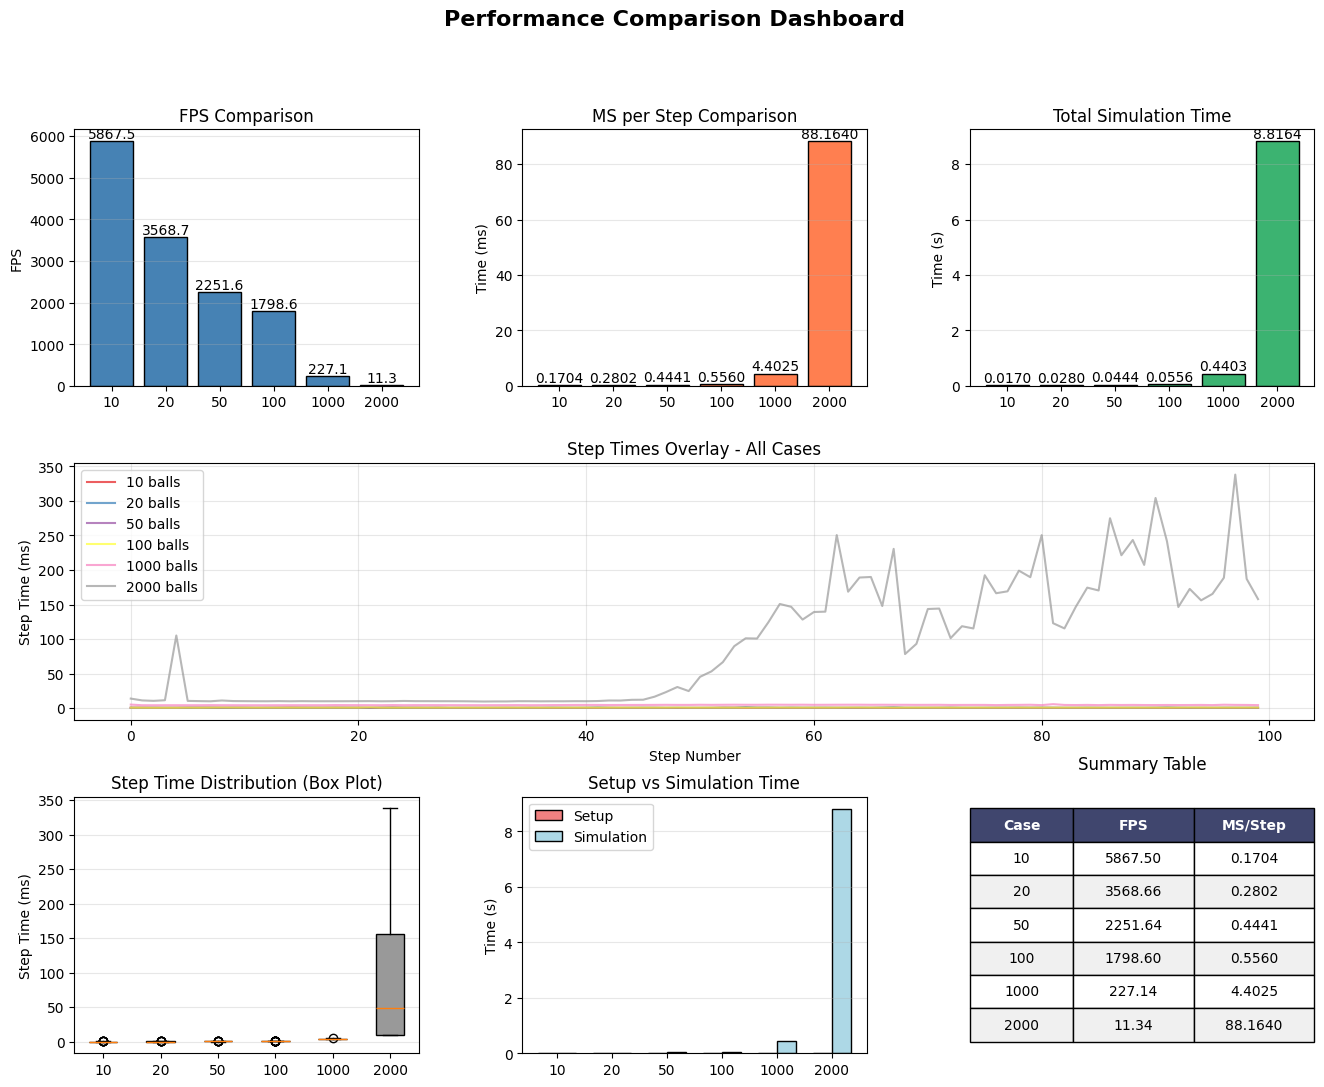

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

def visualize_performance_dashboards(results_dict):
    """
    Create individual dashboards for each case and a comparison dashboard.

    Args:
        results_dict: Dict with structure {n_balls: {'n_balls': int, 'fps': float,
                     'ms_per_step': float, 'steps_time': list, ...}}
    """
    cases = sorted(results_dict.keys())

    # ========== INDIVIDUAL DASHBOARDS ==========
    for case in cases:
        data = results_dict[case]
        fig = plt.figure(figsize=(14, 10))
        fig.suptitle(f"Performance Dashboard - {data['n_balls']} Balls", fontsize=16, fontweight='bold')

        gs = GridSpec(3, 2, figure=fig, hspace=0.3, wspace=0.3)

        # 1. Key Metrics (text)
        ax1 = fig.add_subplot(gs[0, :])
        ax1.axis('off')
        metrics_text = f"""
        FPS: {data['fps']:.2f}  |  MS/Step: {data['ms_per_step']:.4f}  |  Total Sim Time: {data['sim_time_s']:.4f}s  |  Setup Time: {data['add_time_s']:.6f}s  |  Steps: {data['n_steps']}
        """
        ax1.text(0.5, 0.5, metrics_text, ha='center', va='center', fontsize=12,
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

        # 2. Step times distribution
        ax2 = fig.add_subplot(gs[1, 0])
        steps = np.array(data['steps_time']) * 1000  # Convert to ms
        ax2.plot(steps, linewidth=0.8, color='blue')
        ax2.axhline(steps.mean(), color='red', linestyle='--', label=f'Mean: {steps.mean():.4f}ms')
        ax2.set_ylabel('Step Time (ms)')
        ax2.set_xlabel('Step Number')
        ax2.set_title('Step Times Over Simulation')
        ax2.grid(alpha=0.3)
        ax2.legend()

        # 3. Step times histogram
        ax3 = fig.add_subplot(gs[1, 1])
        ax3.hist(steps, bins=50, color='green', alpha=0.7, edgecolor='black')
        ax3.axvline(steps.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {steps.mean():.4f}ms')
        ax3.axvline(np.median(steps), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(steps):.4f}ms')
        ax3.set_xlabel('Step Time (ms)')
        ax3.set_ylabel('Frequency')
        ax3.set_title('Step Time Distribution')
        ax3.legend()
        ax3.grid(alpha=0.3, axis='y')

        # 4. Statistics box
        ax4 = fig.add_subplot(gs[2, 0])
        ax4.axis('off')
        stats_text = f"""Step Time Statistics:
Min: {steps.min():.4f}ms
Max: {steps.max():.4f}ms
Mean: {steps.mean():.4f}ms
Median: {np.median(steps):.4f}ms
Std Dev: {steps.std():.4f}ms
"""
        ax4.text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

        # 5. Time breakdown pie chart
        ax5 = fig.add_subplot(gs[2, 1])
        sizes = [data['add_time_s'], data['sim_time_s']]
        labels = [f"Setup: {data['add_time_s']:.6f}s", f"Simulation: {data['sim_time_s']:.4f}s"]
        colors = ['#ff9999', '#66b3ff']
        ax5.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
        ax5.set_title('Time Breakdown')

        plt.show()

    # ========== COMPARISON DASHBOARD ==========
    fig = plt.figure(figsize=(16, 12))
    fig.suptitle("Performance Comparison Dashboard", fontsize=16, fontweight='bold')

    gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

    # Extract data for all cases
    fps_values = [results_dict[c]['fps'] for c in cases]
    ms_per_step = [results_dict[c]['ms_per_step'] for c in cases]
    sim_times = [results_dict[c]['sim_time_s'] for c in cases]
    add_times = [results_dict[c]['add_time_s'] for c in cases]

    # 1. FPS Comparison
    ax1 = fig.add_subplot(gs[0, 0])
    bars1 = ax1.bar([str(c) for c in cases], fps_values, color='steelblue', edgecolor='black')
    ax1.set_ylabel('FPS')
    ax1.set_title('FPS Comparison')
    ax1.grid(axis='y', alpha=0.3)
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom')

    # 2. MS per Step Comparison
    ax2 = fig.add_subplot(gs[0, 1])
    bars2 = ax2.bar([str(c) for c in cases], ms_per_step, color='coral', edgecolor='black')
    ax2.set_ylabel('Time (ms)')
    ax2.set_title('MS per Step Comparison')
    ax2.grid(axis='y', alpha=0.3)
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom')

    # 3. Total Simulation Time
    ax3 = fig.add_subplot(gs[0, 2])
    bars3 = ax3.bar([str(c) for c in cases], sim_times, color='mediumseagreen', edgecolor='black')
    ax3.set_ylabel('Time (s)')
    ax3.set_title('Total Simulation Time')
    ax3.grid(axis='y', alpha=0.3)
    for bar in bars3:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom')

    # 4. Step times overlay (all cases)
    ax4 = fig.add_subplot(gs[1, :])
    colors_plot = plt.cm.Set1(np.linspace(0, 1, len(cases)))
    for i, case in enumerate(cases):
        steps = np.array(results_dict[case]['steps_time']) * 1000
        ax4.plot(steps, label=f'{case} balls', linewidth=1.5, color=colors_plot[i], alpha=0.7)
    ax4.set_ylabel('Step Time (ms)')
    ax4.set_xlabel('Step Number')
    ax4.set_title('Step Times Overlay - All Cases')
    ax4.legend()
    ax4.grid(alpha=0.3)

    # 5. Box plot of step times
    ax5 = fig.add_subplot(gs[2, 0])
    step_times_all = [np.array(results_dict[c]['steps_time']) * 1000 for c in cases]
    bp = ax5.boxplot(step_times_all, labels=[str(c) for c in cases], patch_artist=True)
    for patch, color in zip(bp['boxes'], colors_plot):
        patch.set_facecolor(color)
    ax5.set_ylabel('Step Time (ms)')
    ax5.set_title('Step Time Distribution (Box Plot)')
    ax5.grid(axis='y', alpha=0.3)

    # 6. Setup vs Simulation Time
    ax6 = fig.add_subplot(gs[2, 1])
    x = np.arange(len(cases))
    width = 0.35
    bars_add = ax6.bar(x - width/2, add_times, width, label='Setup', color='lightcoral', edgecolor='black')
    bars_sim = ax6.bar(x + width/2, sim_times, width, label='Simulation', color='lightblue', edgecolor='black')
    ax6.set_ylabel('Time (s)')
    ax6.set_title('Setup vs Simulation Time')
    ax6.set_xticks(x)
    ax6.set_xticklabels([str(c) for c in cases])
    ax6.legend()
    ax6.grid(axis='y', alpha=0.3)

    # 7. Summary table
    ax7 = fig.add_subplot(gs[2, 2])
    ax7.axis('off')

    table_data = []
    table_data.append(['Case', 'FPS', 'MS/Step'])
    for i, case in enumerate(cases):
        table_data.append([str(case), f'{fps_values[i]:.2f}', f'{ms_per_step[i]:.4f}'])

    table = ax7.table(cellText=table_data, cellLoc='center', loc='center',
                     colWidths=[0.3, 0.35, 0.35])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)

    # Style header row
    for i in range(3):
        table[(0, i)].set_facecolor('#40466e')
        table[(0, i)].set_text_props(weight='bold', color='white')

    # Alternate row colors
    for i in range(1, len(table_data)):
        for j in range(3):
            table[(i, j)].set_facecolor('#f0f0f0' if i % 2 == 0 else 'white')

    ax7.set_title('Summary Table', pad=20)

    plt.show()

# Usage:
visualize_performance_dashboards(res)